# Load Data


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, classification_report, precision_score, confusion_matrix, roc_auc_score, precision_recall_curve, balanced_accuracy_score, recall_score, precision_recall_curve, f1_score, roc_curve)
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.decomposition import PCA, KernelPCA

In [2]:
df = pd.read_csv(r'C:\Users\HP\Desktop\Binary Classification\Diabetes Prediction\data\diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# EDA


In [7]:
# Suspicious values
suspicious = (
    (df['Glucose']<50) | (df['Glucose']>300) |
    (df['BloodPressure']<40) | (df['BloodPressure']>120) |
    (df['SkinThickness']>70) |
    (df['BMI']<15) | (df['BMI']>70) |
    (df['Insulin']>500) |
    (df['Age']>100)
)
print(f'Suspicious values: {suspicious.sum()}')

Suspicious values: 60


In [8]:
# Insulin seems suspecious
upper = df[df['Insulin'] >= df['Insulin'].quantile(0.99)]

zero_insulin = df[df['Insulin'] == 0]
zero_insulin

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
5,5,116,74,0,0,25.6,0.201,30,0
7,10,115,0,0,0,35.3,0.134,29,0
...,...,...,...,...,...,...,...,...,...
761,9,170,74,31,0,44.0,0.403,43,1
762,9,89,62,0,0,22.5,0.142,33,0
764,2,122,70,27,0,36.8,0.340,27,0
766,1,126,60,0,0,30.1,0.349,47,1


In [9]:
upper_insulin = df[df['Insulin'] >=500]
upper_insulin

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
8,2,197,70,45,543,30.5,0.158,53,1
13,1,189,60,23,846,30.1,0.398,59,1
228,4,197,70,39,744,36.7,2.329,31,0
247,0,165,90,33,680,52.3,0.427,23,0
286,5,155,84,44,545,38.7,0.619,34,0
409,1,172,68,49,579,42.4,0.702,28,1
584,8,124,76,24,600,28.7,0.687,52,1
655,2,155,52,27,540,38.7,0.240,25,1
753,0,181,88,44,510,43.3,0.222,26,1


In [10]:
BloodPressure = df[(df['BloodPressure'] < 50) & (df['BloodPressure']!= 0)]
BloodPressure

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137,40,35,168,43.1,2.288,33,1
18,1,103,30,38,83,43.3,0.183,33,0
75,1,0,48,20,0,24.7,0.140,22,0
80,3,113,44,13,0,22.4,0.140,22,0
97,1,71,48,18,76,20.4,0.323,22,0
117,5,78,48,0,0,33.7,0.654,25,0
125,1,88,30,42,99,55.0,0.496,26,1
293,1,128,48,45,194,40.5,0.613,24,1
346,1,139,46,19,83,28.7,0.654,22,0
405,2,123,48,32,165,42.1,0.520,26,0


In [11]:
cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

In [12]:
df.isna().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [13]:
df.corr()['Outcome'].sort_values(ascending=False)

Outcome                     1.000000
Glucose                     0.494650
BMI                         0.313680
Insulin                     0.303454
SkinThickness               0.259491
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
BloodPressure               0.170589
Name: Outcome, dtype: float64

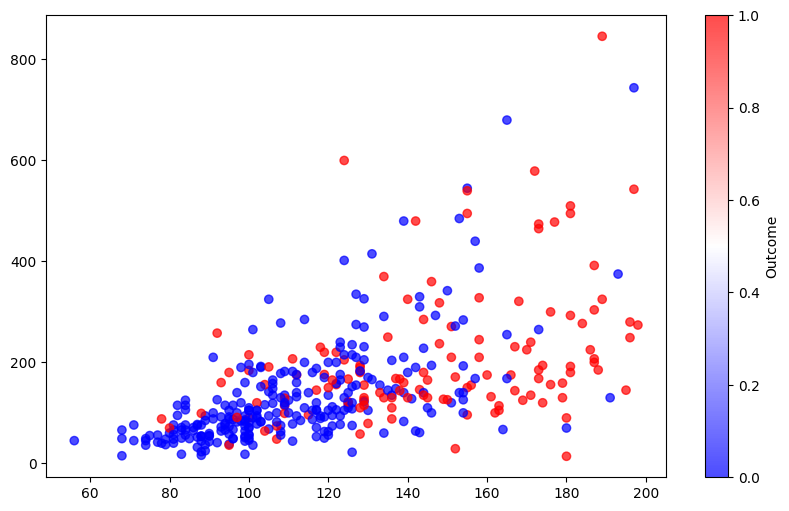

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Glucose'], df['Insulin'], c=df['Outcome'], cmap='bwr', alpha=0.7)
plt.colorbar(label='Outcome')

In [15]:
df['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

<Axes: xlabel='Outcome'>

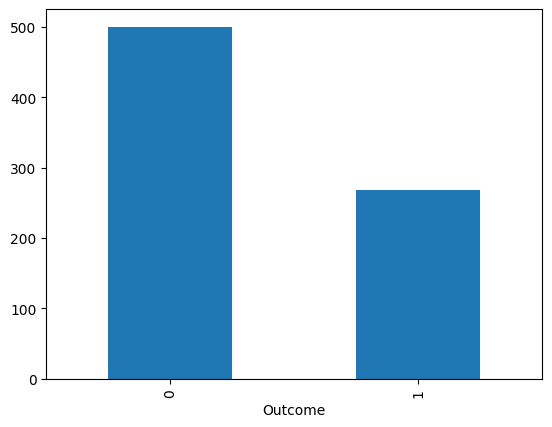

In [16]:
df['Outcome'].value_counts().plot(kind='bar')

Text(0.5, 1.0, 'Heat map')

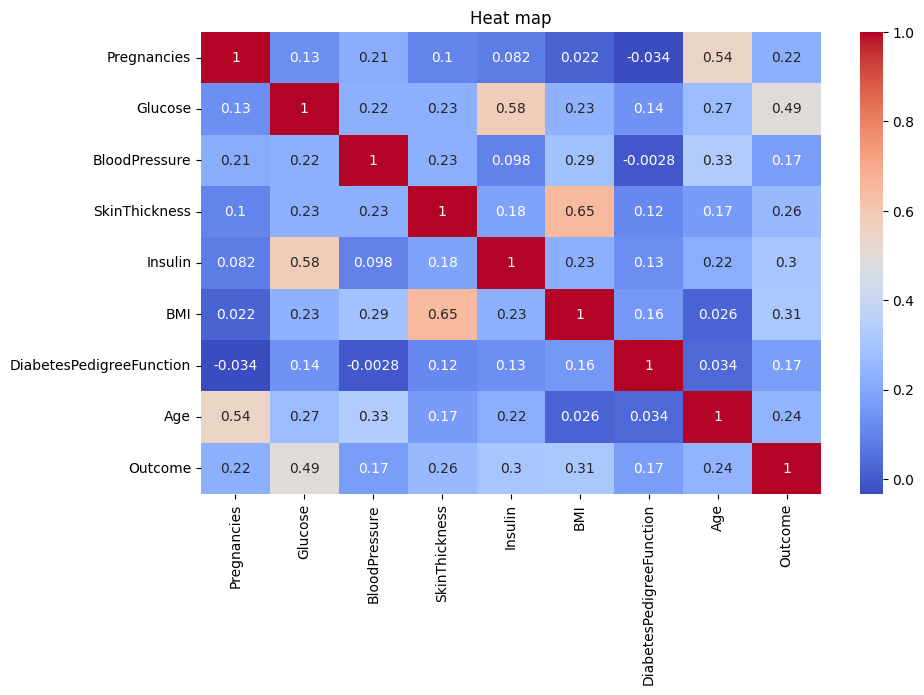

In [17]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True, fmt=".2g")
plt.title("Heat map")

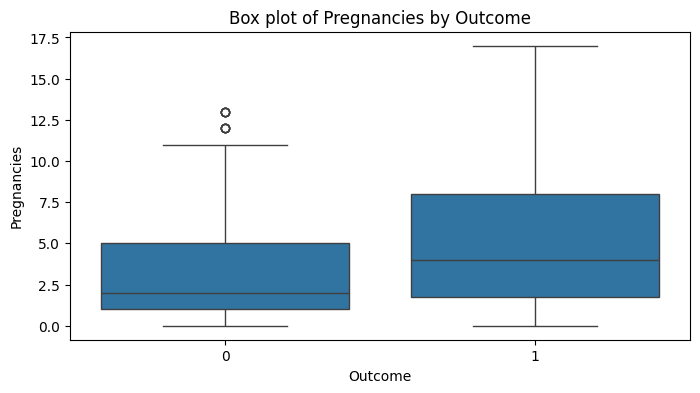

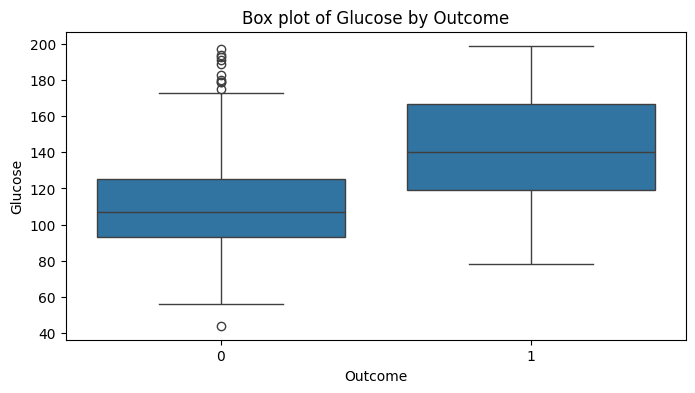

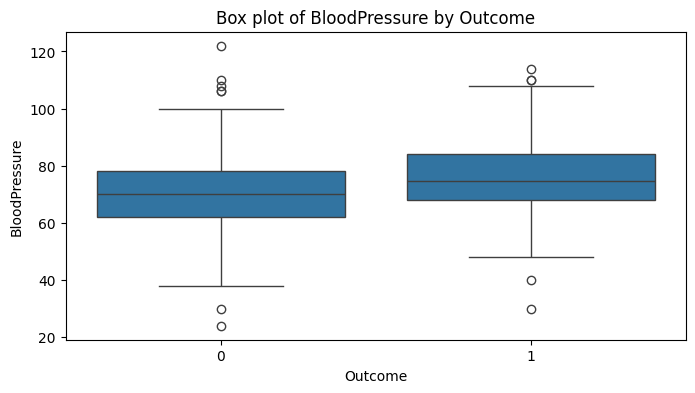

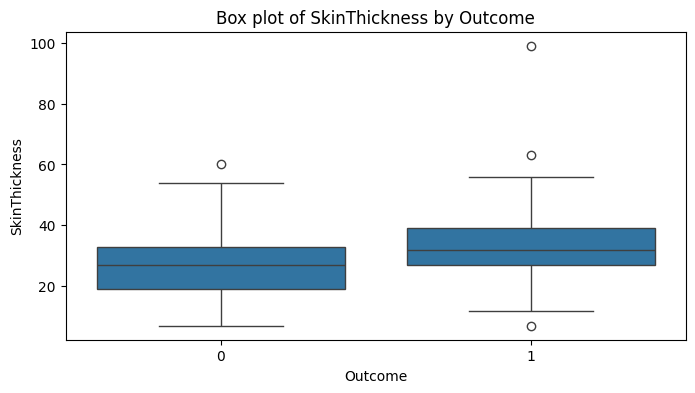

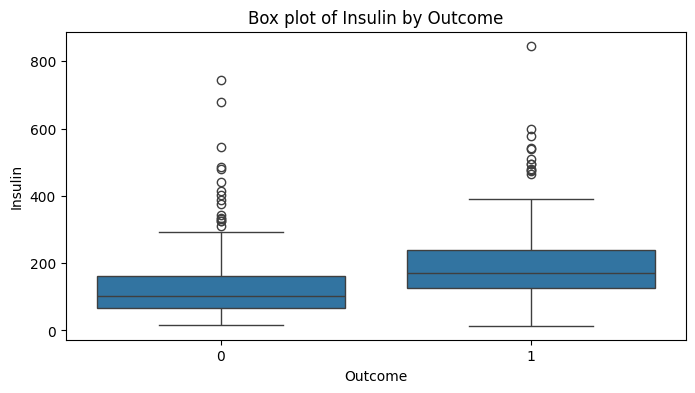

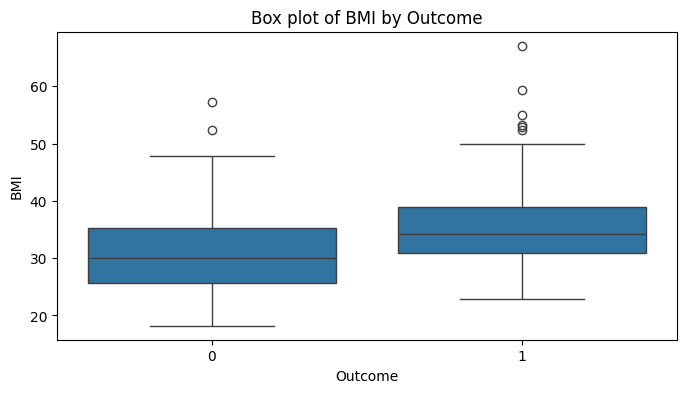

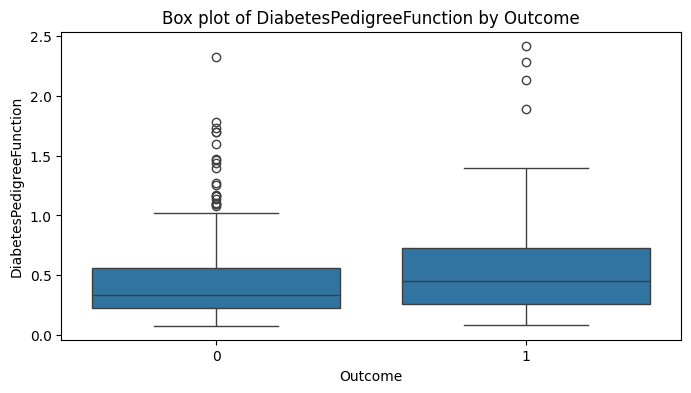

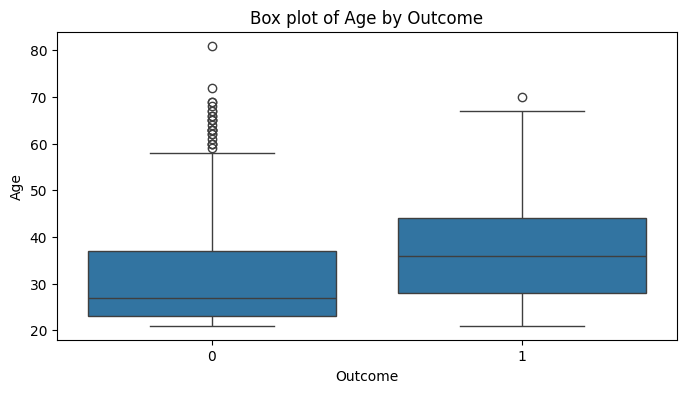

In [18]:
for col in df.columns:
    if col != 'Outcome':
        plt.figure(figsize=(8, 4))
        sns.boxplot(x='Outcome', y=col, data=df)
        plt.title(f'Box plot of {col} by Outcome')

## Build pipeline


In [19]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [21]:
# # Take care of missing values
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

# imputer = IterativeImputer(max_iter=10, random_state=42)
# X_train_imputed = imputer.fit_transform(X_train)
# X_test_imputed = imputer.transform(X_test)

## Random Forest


In [22]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [50,70,100],
    'criterion':['gini', 'entropy', 'log_loss'],
    'max_depth':[None, 5, 10],
    'min_samples_leaf':[1,2,3],
    'max_features': ['sqrt', 'log2'],
    'min_weight_fraction_leaf': [0, 1, 2],
    'bootstrap': [True, False],
    'oob_score': [False, True],
    'min_samples_leaf': [1, 2, 3],
    'class_weight': [None, 'balanced', 'balanced_subsample']
}
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=3, verbose=2)

In [ ]:
# grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 5832 candidates, totalling 17496 fits
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.4s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.2s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=False; total time=   0.2s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estimators=50, oob_score=True; total time=   0.4s
[CV] END bootstrap=True, class_weight=None, criterion=gini, max_depth=None, max_features=sqrt, min_samples_leaf=1, min_weight_fraction_leaf=0, n_estima

KeyboardInterrupt: 

In [ ]:
grid_search.best_estimator_

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



In [ ]:
rf_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})
rf_metrics

,Metric,Score
0,Accuracy,0.733766
1,Balanced Accuracy,0.716162
2,Precision,0.620690
3,ROC AUC,0.716162
4,Recall Score,0.654545


## Baseline Model


In [ ]:
def baseline_pipeline(Scaler, Sampler, Model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ('sl', Scaler),
        ('smp', Sampler),
        ('mdl', Model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))
    return pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})    

In [ ]:
baseline_pipeline(Scaler=MinMaxScaler(), Sampler=RandomOverSampler(random_state=42), Model=XGBClassifier(random_state=42), X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        99
           1       0.56      0.67      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.70       154



,Metric,Score
0,Accuracy,0.694805
1,Balanced Accuracy,0.689899
2,Precision,0.560606
3,ROC AUC,0.689899
4,Recall Score,0.672727


In [ ]:
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('sampler', RandomOverSampler(random_state=42)),
    ('lr', XGBClassifier(random_state=42))
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('sampler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,sampling_strategy,'auto'
,random_state,42
,shrinkage,None
,objective,'binary:logistic'


In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.71      0.75        99
           1       0.56      0.67      0.61        55

    accuracy                           0.69       154
   macro avg       0.68      0.69      0.68       154
weighted avg       0.71      0.69      0.70       154



### Baseline model report

              precision    recall  f1-score   support

           0       0.70      0.81      0.75        85
           1       0.71      0.57      0.63        69

    accuracy                           0.70       154


In [ ]:
confusion_matrix(y_test, y_pred)

array([[70, 29],
       [18, 37]])

In [ ]:
baseline_model_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})
baseline_model_metrics

,Metric,Score
0,Accuracy,0.694805
1,Balanced Accuracy,0.689899
2,Precision,0.560606
3,ROC AUC,0.689899
4,Recall Score,0.672727


In [ ]:
roc_auc_score(y_test, y_pred)

0.68989898989899

In [ ]:
precision_recall_curve(y_test, y_pred)

(array([0.35714286, 0.56060606, 1.        ]),
 array([1.        , 0.67272727, 0.        ]),
 array([0, 1]))

In [ ]:
balanced_accuracy_score(y_test, y_pred)

0.6898989898989899

In [ ]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [ ]:
data = [(6, 148, 72, 35, 0, 33.6, 0.627, 50)]
test = pd.DataFrame(data, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])

In [ ]:
test

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50


In [ ]:
pipe.predict(test)

array([1])

In [ ]:
data2 = [(1, 85, 66, 29, 0, 26.6, 0.351, 31)]
test2 = pd.DataFrame(data2, columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'])
pipe.predict(test2)

array([0])

## KNNImputer + PCA model


In [ ]:
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNNImputer(n_neighbors=5)),
    ('sampler', RandomOverSampler()),
    ('fe', PCA(n_components=2)),
    ('lr', XGBClassifier(random_state=42))
])

pipe.fit(X_train, y_train)

,steps,"[('scaler', ...), ('knn', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,feature_range,"(0, ...)"
,copy,True
,clip,False
,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'


In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.68      0.72        99
           1       0.52      0.62      0.56        55

    accuracy                           0.66       154
   macro avg       0.64      0.65      0.64       154
weighted avg       0.67      0.66      0.66       154



### Model with PCA

              precision    recall  f1-score   support

           0       0.72      0.86      0.78        85
           1       0.77      0.59      0.67        69

    accuracy                           0.74       154


In [ ]:
pca_model_metrics = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})
pca_model_metrics

,Metric,Score
0,Accuracy,0.655844
1,Balanced Accuracy,0.647475
2,Precision,0.515152
3,ROC AUC,0.647475
4,Recall Score,0.618182


In [ ]:
# Take care of missing values
imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

## Impute model only


In [ ]:
def Impute_pipeline(Imputer, Scaler, Sampler, Model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ('imp', Imputer),
        ('sl', Scaler),
        ('smp', Sampler),
        ('mdl', Model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))
    return pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})    

In [ ]:
Impute_pipeline(Imputer=IterativeImputer(max_iter=10, random_state=42), Scaler=MinMaxScaler(), Sampler=RandomOverSampler(random_state=42), Model=XGBClassifier(random_state=42), X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

              precision    recall  f1-score   support

           0       0.82      0.76      0.79        99
           1       0.61      0.69      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



,Metric,Score
0,Accuracy,0.733766
1,Balanced Accuracy,0.724242
2,Precision,0.612903
3,ROC AUC,0.724242
4,Recall Score,0.690909


## Impute and PCA model


In [ ]:
def Impute_PCA_pipeline(Imputer, Scaler, Sampler, Model, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ('imp', Imputer),
        ('sl', Scaler),
        ('smp', Sampler),
        ('fe', PCA(n_components=2)),
        ('mdl', Model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))
    return pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred)
    ]
})    

In [ ]:
Impute_PCA_pipeline(Imputer=IterativeImputer(max_iter=10, random_state=42), Scaler=MinMaxScaler(), Sampler=RandomOverSampler(random_state=42), Model=XGBClassifier(random_state=42), X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)

              precision    recall  f1-score   support

           0       0.83      0.73      0.77        99
           1       0.60      0.73      0.66        55

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



,Metric,Score
0,Accuracy,0.727273
1,Balanced Accuracy,0.727273
2,Precision,0.597015
3,ROC AUC,0.727273
4,Recall Score,0.727273


## Feature Engineer


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,NaN,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,NaN,NaN,30.1,0.349,47,1


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
        # # Engineer features
        # X['BMI_Obese'] = (X['BMI'] >= 30).astype(int)
        # X['BMI_underweight'] = (X['BMI']<16).astype(int)
        # X['Glucose_Diabetes'] = (X['Glucose'] >= 126).astype(int)
        # X['Age_Senior'] = (X['Age'] >= 50).astype(int)

In [ ]:
df[df['DiabetesPedigreeFunction']>=2.2]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
228,4,197.0,70.0,39.0,744.0,36.7,2.329,31,0
445,0,180.0,78.0,63.0,14.0,59.4,2.420,25,1


In [ ]:
# Custom transformer
from sklearn.base import BaseEstimator, TransformerMixin
class MedicalFeatureEngineer(BaseEstimator, TransformerMixin):
    def _init_(self):
        self.feature_names_out_ = None
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.feature_names_in_) if not isinstance(X, pd.DataFrame) else X.copy()
        
        # Engineer features
        X['BMI_Obese'] = (X['BMI'] >= 30).astype(int)
        X['BMI_underweight'] = (X['BMI']<18).astype(int)
        X['Glucose_Diabetes'] = (X['Glucose'] >= 126).astype(int)
        X['Age_lower'] = (X['Age']>=18).astype(int)
        X['Age_Senior'] = (X['Age'] >= 50).astype(int)
        X['Low_glucose'] = (X['Glucose']<44).astype(int)
        X['low_chance'] = (X['DiabetesPedigreeFunction']<0.088).astype(int)
        X['High_chance'] = (X['DiabetesPedigreeFunction']>2.42).astype(int)

        # # Ratio Features
        # X['Glucose_BMI_Ratio'] = X['Glucose'] / (X['BMI']+1e-5)
        # X['Glucose_Age_Ratio'] = X['Glucose'] / (X['Age']+1e-5)
        # X['Glucose_DPF_Ratio'] = X['Glucose'] / (X['DiabetesPedigreeFunction']+1e-5)
        
        self.feature_names_out_ = X.columns.tolist()
        return X
    
    def fit_transform(self, X, y=None):
        self.feature_names_in_ = X.columns.tolist() if isinstance(X, pd.DataFrame) else [f'feature_{i}' for i in range(X.shape[1])]
        return self.fit(X, y).transform(X)
    
    def get_feature_names_out(self, input_features=None):
        return self.feature_names_out_

## Voting Classifier

- I used it as it increased recall score


In [ ]:
from sklearn.preprocessing import FunctionTransformer

def to_dataframe(X, columns):
    return pd.DataFrame(X, columns=columns)
def Feature_Engineer_pipeline(Imputer, Scaler, Sampler, Model, X_train, y_train, X_test, y_test):

    pipe = Pipeline([
        ('imp', Imputer),
        ('to_df', FunctionTransformer(lambda X: to_dataframe(X, X_train.columns), validate=False)),
        ('feature_engineering', MedicalFeatureEngineer()),
        ('sl', Scaler),
        ('smp', Sampler),
        ('fe', PCA(n_components=2)),
        ('mdl', Model)
    ])


    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred))
    return pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score', 'f1 score'],
    'Score': [
        accuracy_score(y_test, y_pred),
        balanced_accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        roc_auc_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})    

In [31]:
from sklearn.ensemble import VotingClassifier
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,

 subsample= 0.8,
 scale_pos_weight= scale_pos_weight,
 reg_lambda= 1,
 reg_alpha= 0,
 n_estimators= 300,
 min_child_weight= 5,
 max_depth= 4,
 learning_rate= 0.05,
 gamma= 0.4,
 colsample_bytree= 0.7
)

log_reg = RandomForestClassifier(min_samples_leaf=4, min_weight_fraction_leaf=0,
                       n_estimators=300, random_state=42, max_depth=10, min_samples_split=10, max_features='sqrt', bootstrap=True, oob_score=True, class_weight='balanced')
voting = VotingClassifier(
    estimators=[('xgb', xgb), ('logreg', log_reg)], voting="soft"#, weights=[2,1]
)
Feature_Engineer_pipeline(
    Imputer=IterativeImputer(max_iter=10, random_state=42),
    Scaler=MinMaxScaler(),
    Sampler=RandomOverSampler(random_state=42),
    Model=voting,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [11:12:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.88      0.64      0.74        99
           1       0.56      0.84      0.67        55

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.70       154
weighted avg       0.76      0.71      0.71       154



,Metric,Score
0,Accuracy,0.707792
1,Balanced Accuracy,0.736364
2,Precision,0.560976
3,ROC AUC,0.736364
4,Recall Score,0.836364
5,f1 score,0.671533


In [ ]:
c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [11:08:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
              precision    recall  f1-score   support

           0       0.87      0.73      0.79        99
           1       0.62      0.80      0.70        55

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154

Metric	Score
0	Accuracy	0.753247
1	Balanced Accuracy	0.763636
2	Precision	0.619718
3	ROC AUC	0.763636
4	Recall Score	0.800000
5	f1 score	0.698413


In [ ]:
# # Create and use the full pipeline
# pipe = Pipeline([
#     ('imp', IterativeImputer(max_iter=10, random_state=42)),
#     ('to_df', FunctionTransformer(lambda X: pd.DataFrame(X, columns=X_train.columns), validate=False)),
#     ('feature_engineering', MedicalFeatureEngineer()),
#     ('sl', MinMaxScaler()),
#     ('smp', RandomOverSampler(random_state=42)),
#     ('fe', PCA(n_components=2)),
#     ('mdl', voting)
# ])

# # Fit the pipeline
# pipe.fit(X_train, y_train)

# # Get prediction probabilities for the first sample
# pipe.predict_proba(X_test.iloc[[0]])

c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [11:14:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


array([[0.46012441, 0.53987559]])

## Threshold Tuning


In [89]:
y_probs = pipe.predict_proba(X_test)[:, 1]

In [90]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

In [91]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

In [92]:
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold:\n{best_threshold:.3f}")
print(f"Best F1-score:\n{np.max(f1_scores):.3f}")

Best threshold:
0.199
Best F1-score:
0.652


In [132]:
y_pred_tuned = (y_probs >= 0.021881).astype(int)
print(classification_report(y_test, y_pred_tuned))
metrics_tt = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Precision', 'ROC AUC', 'Recall Score', 'f1 score'],
    'Score': [
        accuracy_score(y_test, y_pred_tuned),
        balanced_accuracy_score(y_test, y_pred_tuned),
        precision_score(y_test, y_pred_tuned),
        roc_auc_score(y_test, y_pred_tuned),
        recall_score(y_test, y_pred_tuned),
        f1_score(y_test, y_pred_tuned)
    ]
})
metrics_tt

              precision    recall  f1-score   support

           0       0.95      0.40      0.57        99
           1       0.47      0.96      0.63        55

    accuracy                           0.60       154
   macro avg       0.71      0.68      0.60       154
weighted avg       0.78      0.60      0.59       154



,Metric,Score
0,Accuracy,0.603896
1,Balanced Accuracy,0.683838
2,Precision,0.473214
3,ROC AUC,0.683838
4,Recall Score,0.963636
5,f1 score,0.634731


In [ ]:
             precision    recall  f1-score   support

           0       0.95      0.40      0.57        99
           1       0.47      0.96      0.63        55

    accuracy                           0.60       154
   macro avg       0.71      0.68      0.60       154
weighted avg       0.78      0.60      0.59       154

Metric	Score
0	Accuracy	0.603896
1	Balanced Accuracy	0.683838
2	Precision	0.473214
3	ROC AUC	0.683838
4	Recall Score	0.963636
5	f1 score	0.634731


In [105]:
target_recall = 0.9
idx = np.where(recalls >= target_recall)[0][0]
threshold_for_recall = thresholds[idx]

In [106]:
threshold_for_recall

np.float32(0.00031635276)

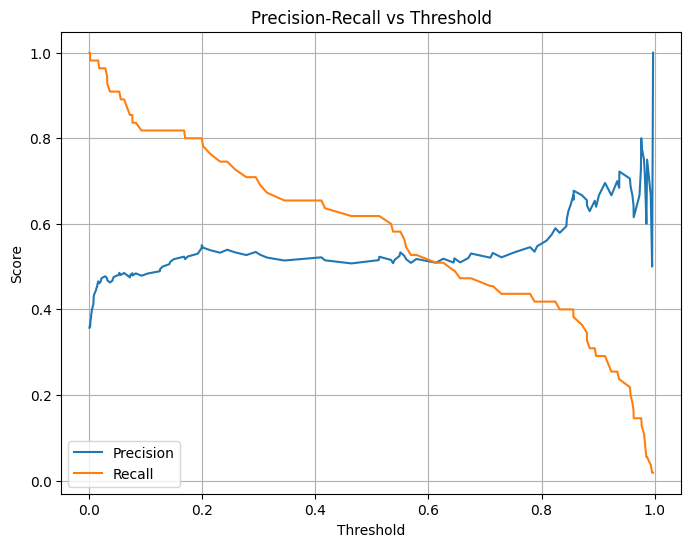

In [125]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probabilities for positive class
y_probs = pipe.predict_proba(X_test)[:, 1]

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Plot
plt.figure(figsize=(8,6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()


In [129]:
thresholds.shape, precisions.shape, recalls.shape

((148,), (149,), (149,))

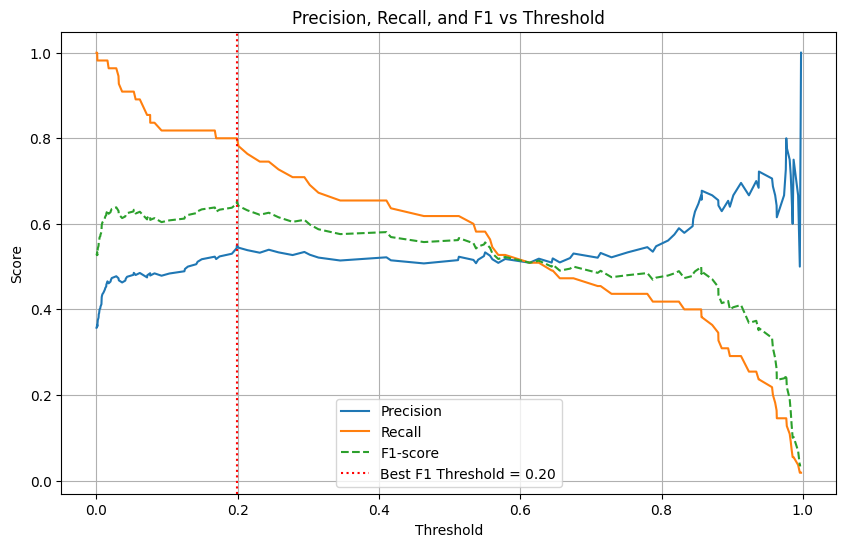

Best Threshold (F1): 0.199
Best F1 Score: 0.652


In [128]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Get probabilities for positive class
y_probs = pipe.predict_proba(X_test)[:, 1]

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Compute F1 scores
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-6)  # add epsilon to avoid /0

# Plot Precision and Recall vs Threshold
plt.figure(figsize=(10,6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1-score", linestyle="--")

# Highlight best F1
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]
plt.axvline(best_threshold, color='r', linestyle=':', label=f"Best F1 Threshold = {best_threshold:.2f}")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Threshold (F1): {best_threshold:.3f}")
print(f"Best F1 Score: {best_f1:.3f}")


In [133]:
import pandas as pd
from sklearn.metrics import precision_recall_curve

# Compute precision, recall, thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# Slice to match lengths (thresholds is shorter by 1)
df_pr = pd.DataFrame({
    "threshold": thresholds,
    "precision": precisions[:-1],
    "recall": recalls[:-1],
    "f1_score": 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-6)
})

# Optional: sort by F1 score descending
df_pr_sorted = df_pr.sort_values(by="f1_score", ascending=False)

# Display top rows
print(df_pr_sorted.head(20))

    threshold  precision    recall  f1_score
69   0.198974   0.550000  0.800000  0.651851
68   0.198689   0.543210  0.800000  0.647058
67   0.195216   0.536585  0.800000  0.642335
70   0.201268   0.544304  0.781818  0.641791
38   0.028317   0.477477  0.963636  0.638554
63   0.167742   0.523256  0.818182  0.638297
66   0.191905   0.530120  0.800000  0.637681
37   0.021881   0.473214  0.963636  0.634730
62   0.149282   0.517241  0.818182  0.633802
65   0.174467   0.523810  0.800000  0.633093
46   0.053101   0.485437  0.909091  0.632911
33   0.015828   0.465517  0.981818  0.631579
71   0.213826   0.538462  0.763636  0.631578
36   0.020757   0.469027  0.963636  0.630952
39   0.031417   0.472727  0.945455  0.630303
61   0.143418   0.511364  0.818182  0.629370
45   0.052612   0.480769  0.909091  0.628930
64   0.169623   0.517647  0.800000  0.628571
48   0.061634   0.485149  0.890909  0.628205
32   0.014999   0.461538  0.981818  0.627907


In [134]:
thresholds = np.linspace(0, 1, 100)
scores = []
for t in thresholds:
    y_pred = (y_probs >= t).astype(int)
    scores.append(f1_score(y_test, y_pred))   # or precision, recall, etc.
best_t = thresholds[np.argmax(scores)]
best_t

np.float64(0.19191919191919193)

## RandomizedrchCV


In [61]:
{'subsample': 1.0,
 'scale_pos_weight': 1,
 'reg_lambda': 1,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.4,
 'colsample_bytree': 0.7}

{'subsample': 1.0,
 'scale_pos_weight': 1,
 'reg_lambda': 1,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.4,
 'colsample_bytree': 0.7}

In [62]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.2, 0.4],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],       # L1 regularization
    'reg_lambda': [1, 5, 10],         # L2 regularization
    'scale_pos_weight': [1, 2, 3, 5]  # for imbalance; tune based on class ratio
}

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)

search = RandomizedSearchCV(
    estimator = xgb,
    scoring='recall', # use 'roc_auc' or 'f1' for imbalance
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    n_jobs=-1
)

search.fit(X_train, y_train)

c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'gamma': [0, 0.2, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,100
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [63]:
search.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 5,
 'reg_lambda': 5,
 'reg_alpha': 0.1,
 'n_estimators': 100,
 'min_child_weight': 3,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [64]:
{'subsample': 1.0,
 'scale_pos_weight': 1,
 'reg_lambda': 1,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.4,
 'colsample_bytree': 0.7}

{'subsample': 1.0,
 'scale_pos_weight': 1,
 'reg_lambda': 1,
 'reg_alpha': 0,
 'n_estimators': 100,
 'min_child_weight': 5,
 'max_depth': 3,
 'learning_rate': 0.01,
 'gamma': 0.4,
 'colsample_bytree': 0.7}

## StackingClassifier


In [65]:
from sklearn.ensemble import StackingClassifier
scale_pos_weight = (y_train==0).sum() / (y_train==1).sum()

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42,

 subsample= 0.8,
 scale_pos_weight= scale_pos_weight,
 reg_lambda= 1,
 reg_alpha= 0,
 n_estimators= 300,
 min_child_weight= 5,
 max_depth= 4,
 learning_rate= 0.05,
 gamma= 0.4,
 colsample_bytree= 0.7
)

log_reg = RandomForestClassifier(min_samples_leaf=4, min_weight_fraction_leaf=0,
                       n_estimators=300, random_state=42, max_depth=10, min_samples_split=10, max_features='sqrt', bootstrap=True, oob_score=True, class_weight='balanced')
stack = StackingClassifier(
    estimators=[('xgb', xgb), ('logreg', log_reg)], final_estimator=RandomForestClassifier(min_samples_leaf=4, min_weight_fraction_leaf=0,
                       n_estimators=300, random_state=42, max_depth=10, min_samples_split=10, max_features='sqrt', bootstrap=True, oob_score=True, class_weight='balanced'), passthrough=True
)
Feature_Engineer_pipeline(
    Imputer=IterativeImputer(max_iter=10, random_state=42),
    Scaler=MinMaxScaler(),
    Sampler=RandomOverSampler(random_state=42),
    Model=stack,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\HP\miniconda3\envs\sklearnenv\lib\site-packages\xgboost\training.py:183: UserWarning: [08:56:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters:

              precision    recall  f1-score   support

           0       0.86      0.71      0.78        99
           1       0.60      0.80      0.69        55

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



,Metric,Score
0,Accuracy,0.740260
1,Balanced Accuracy,0.753535
2,Precision,0.602740
3,ROC AUC,0.753535
4,Recall Score,0.800000


In [67]:

              precision    recall  f1-score   support

           0       0.87      0.73      0.79        99
           1       0.62      0.80      0.70        55

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154

Metric	Score
0	Accuracy	0.753247
1	Balanced Accuracy	0.763636
2	Precision	0.619718
3	ROC AUC	0.763636
4	Recall Score	0.800000


IndentationError: unindent does not match any outer indentation level (<tokenize>, line 6)